# Capstone: Define and Solve an ML Problem

In [1]:
import pandas as pd
import numpy as np
import os 
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder 
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
import tensorflow.keras as keras
from sklearn.preprocessing import StandardScaler
import time

**Note**: As you work through the notebook, you can import additional packages as needed.

## Overview


In this capstone assignment, you will follow the machine learning life cycle and implement one of the supervised learning models you have learned so far in this course, along with a neural network, to solve a predictive problem.

This capstone spans two lab sessions.

- **Unit 5 Lab:** You will define a machine learning problem, explore and prepare your data, and train, test, evaluate and improve a traditional machine learning model (Parts 1–5).
- **Unit 6 Lab:** After completing Unit 6 on neural networks, you will apply a neural network to the same problem and compare the two approaches (Parts 6–7).

There is a checkpoint at the end of Part 5 that marks where to stop during the Unit 5 lab.

You will complete the following:

1. Choose your Data Set and Build Your DataFrame
2. Define Your ML Problem
3. Understand Your Data
4. Prepare Your Data
5. Train, Test, Evaluate and Improve a Traditional Machine Learning Model *(Unit 5 lab)*
6. Train, Test, Evaluate and Improve Neural Network *(Unit 6 lab)*
7. Compare Your Models and Reflect *(Unit 6 lab)*

**This is an individual assignment.** You are welcome to discuss ideas with your peers, but the code and written responses you submit must be your own.

**Note:** This capstone is intentionally less scaffolded than your weekly labs; that is by design. You are expected to make your own implementation choices, add code cells as needed, and document your reasoning throughout.

## Part 1: Choose Your Data Set and Build Your DataFrame


You will choose one of two data sets to work with for this capstone. In both cases, you will be solving a supervised learning binary classification problem by predicting one of two possible class labels. Both data sets have been used earlier in the course, so you are already familiar with their structure. 

**Option A: Census Income Data** (`censusData.csv`)
This data set contains demographic and employment information from the 1994 U.S. Census. You will use it to predict whether an individual's annual income exceeds $50,000. Your label column is `income_binary`, which contains two values: `<=50K` and `>50K`. You will need to convert this column into a binary numeric label (for example, 0 and 1) during data preparation.

**Option B: Airbnb NYC Listings Data** (`airbnbListingsData.csv`)
This data set contains information about Airbnb listings in New York City. You will use it to predict whether a listing is high-priced. The data set includes a new `price_category` column that classifies each listing as either "high price" or "low price" based on whether the listing’s price falls above or below the 75th percentile of all listing prices. Listings at or above the 75th percentile are labeled as `high`, while the remaining listings are labeled as `low`. You will need to convert this column into a binary numeric label (for example, 0 and 1) during data preparation.

**Note:**  These versions of the data sets differ slightly from the versions you have worked with in this program. For example, they may not include some of the preprocessing necessary for specific models. 

#### Load a Data Set and Save it as a Pandas DataFrame

The code cell below contains filenames (path + filename) for the two data sets available to you.

<b>Task:</b> In the code cell below, load your chosen data set using `pd.read_csv()` and save it to a DataFrame named `df`. Then call `df.head()` to inspect the first few row of the data set.

In [2]:
# File paths for both data sets
census_filename = os.path.join(os.getcwd(), "data_capstone", "censusData.csv")
airbnb_filename = os.path.join(os.getcwd(), "data_capstone", "airbnbListingsData.csv")

# Load your chosen dataset and save it to df
df = pd.read_csv("data_capstone/censusData.csv")

df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex_selfID,capital-gain,capital-loss,hours-per-week,native-country,income_binary
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Non-Female,2174,0,40.0,United-States,<=50K
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Non-Female,0,0,13.0,United-States,<=50K
2,38.0,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Non-Female,0,0,40.0,United-States,<=50K
3,53.0,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Non-Female,0,0,40.0,United-States,<=50K
4,28.0,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40.0,Cuba,<=50K


## Part 2: Define Your ML Problem

The first step of the machine learning life cycle involves defining your business problem. In the markdown cell below, you will clearly define what you are trying to predict and why it matters. 

<b>Task</b>: In the markdown cell below, answer all of the following questions:

1. Which data set did you choose?
2. What is your label? What are you predicting?
3. What features do you plan to use? (This list may change after you explore your data.)
5. Why does this problem matter? Using the business brief you read in the lab overview page, explain how the organization described there could use a model that predicts this label to create value or inform decisions for their client.

1. I chose to do the Census dataset to switch it up a bit since we have been doing alot with the airbnb dataset lately
2. The label is 'income_binary', and im trying to predict whether the income is over 50k or less then/equal to 50k
3. Right now im planning to use demographic/employment features, like age, education-num, capital-gain, etc.
4. This problem is very important for organiztations or it's clients, being able to predict income brackets allow for targeted marketing, research, and financial services

## Part 3: Understand Your Data

Now that you have defined your problem, perform exploratory data analysis (EDA) with that problem in mind. Consider the following as you inspect your data:

1. What data preparation techniques would you like to use? These data preparation techniques may include:

    * handling missing values
    * finding and replacing outliers
    * performing feature engineering techniques such as one-hot encoding on categorical features
    * selecting appropriate features and removing irrelevant features
    * addressing class imbalance


2. What machine learning model would you like to use that is suitable for your predictive problem and data?
   * You may use one of the following models that you have worked with so far:
        - K-Nearest Neighbors (KNN)
        - Decision Tree
        - Logistic Regression
   * Are there other data preparation techniques that you will need to apply to build a balanced modeling data set for your problem and model? For example, will you need to scale your data?
 

3. How will you evaluate and improve the model's performance?
    * Are there specific evaluation metrics or methods that are appropriate for your problem, dataset, or selected model?
    
<b>Task</b>: In the code cells below, use the techniques you have learned in this course to inspect and analyze your data.

<b>Note</b>: You can add code cells if needed by going to the <b>Insert</b> menu and clicking on <b>Insert Cell Below</b> in the drop-down menu.

### Class Imbalance

Examine the distribution of your label column to determine whether class imbalance is present. Use at least one visualization to show the class distribution. In the **EDA Summary** below, you will discuss how you plan to address any observed imbalance during data preparation.

Class Counts:
<=50K    24720
>50K      7841
Name: income_binary, dtype: int64
Class Percents:
<=50K    75.92
>50K     24.08
Name: income_binary, dtype: float64


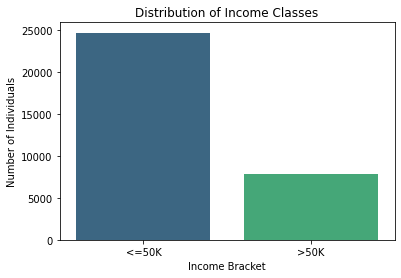

In [3]:
class_counts = df['income_binary'].value_counts()
class_percents = df['income_binary'].value_counts(normalize=True) * 100

print("Class Counts:")
print(class_counts)
print("Class Percents:")
print(class_percents.round(2))

plt.figure(figsize=(6,4))
sns.countplot(x='income_binary', data=df, palette='viridis')
plt.title('Distribution of Income Classes')
plt.xlabel('Income Bracket')
plt.ylabel('Number of Individuals')
plt.show()

### Inspect and Analyze Your Data

Explore your features. Use summary statistics and visualizations to understand how your features are distributed and how they relate to the label. Identify issues such as missing values, outliers, or a feature that is irrelevant or redundant.

Think of the different techniques you have used to inspect and analyze your data in this course. These include using Pandas to apply data filters, using the Pandas `describe()` method to get insight into key statistics for each column, using the Pandas `dtypes` property to inspect the data type of each column, and using Matplotlib and Seaborn to detect outliers and visualize relationships between features and labels. 

Use at least one plot that visualizes a relationship between features and the label.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             32399 non-null  float64
 1   workclass       30725 non-null  object 
 2   fnlwgt          32561 non-null  int64  
 3   education       32561 non-null  object 
 4   education-num   32561 non-null  int64  
 5   marital-status  32561 non-null  object 
 6   occupation      30718 non-null  object 
 7   relationship    32561 non-null  object 
 8   race            32561 non-null  object 
 9   sex_selfID      32561 non-null  object 
 10  capital-gain    32561 non-null  int64  
 11  capital-loss    32561 non-null  int64  
 12  hours-per-week  32236 non-null  float64
 13  native-country  31978 non-null  object 
 14  income_binary   32561 non-null  object 
dtypes: float64(2), int64(4), object(9)
memory usage: 3.7+ MB
NaN/Null counts per column:
age                162
workclass    

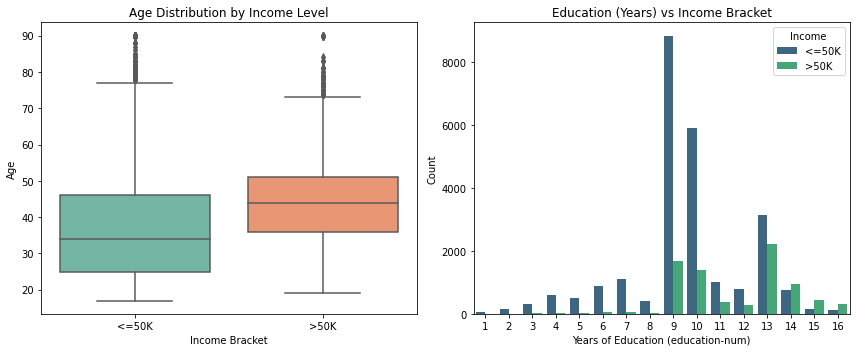

In [4]:
df.info()

#checking for missing values
nan_counts = df.isnull().sum()
print("NaN/Null counts per column:")
print(nan_counts[nan_counts > 0] if nan_counts.sum() > 0 else "No NaN values found.")

#checking for ?
for col in df.columns:
    if df[col].dtype == 'object':
        question_marks = (df[col] == '?').sum()
        if question_marks > 0:
            print(f"Column '{col}' has {question_marks} missing values represented as '?'")
            
#sum stats
print(df.describe())

#visualizing relationship between features & label
plt.figure(figsize=(12, 5))

#1 - age vs income
plt.subplot(1, 2, 1)
sns.boxplot(x='income_binary', y='age', data=df, palette='Set2')
plt.title('Age Distribution by Income Level')
plt.xlabel('Income Bracket')
plt.ylabel('Age')

#2 - education vs income
plt.subplot(1, 2, 2)
sns.countplot(x='education-num', hue='income_binary', data=df, palette='viridis')
plt.title('Education (Years) vs Income Bracket')
plt.xlabel('Years of Education (education-num)')
plt.ylabel('Count')
plt.legend(title='Income')

plt.tight_layout()
plt.show()

### EDA Summary

<b>Task</b>: In the markdown cell below, summarize the key findings from your data exploration. Describe any patterns, anomalies, or data quality issues you identified and explain how those findings may influence your data preparation decisions. For example, your exploration may affect how you handle missing values, address class imbalance, or determine which features to keep or remove.

I found that people with more years of education are much more likely to earn over 50K, also that older people tend to make more money. The median age for the high-income group is around 44, while the lower-income group is around 34.

Missing Data and Issues

There are a few missing values I have to fix:
* age column is missing 162 values.
* workclass column is missing 1,836 values.
* occupation column is missing 1,843 values.
* hours-per-week column is missing 325 values.
* native-country column is missing 583 values.

Side note, the education column and education-num column have the same data, so I'm going to delete one since its kind of redundant.

Since ~76% of the people in the dataset make under 50k and only ~24% make over 50%, I will make sure the data split keeps the same balance so my models learn correctly.

### Ethical Considerations:

Machine learning models can cause harm when they reflect or amplify biases in the data they are trained on. 

<b>Task</b>: In the markdown cell below, answer both of the following questions:

1. What biases or ethical concerns might be present in your dataset? Think about who collected the data, how it was collected, and which groups of people appear in it. Are there features in the dataset that could serve as proxies for protected characteristics like race, gender, or socioeconomic status?
2. Who could be harmed by a model that makes incorrect predictions on this data, and how? Be specific about which groups are most at risk and what the real-world consequences of errors might look like.

Biases and Ethical Concerns

I first noticed that some features are a bit insensitive, like race and sex_selfID. If a model uses these to predict income, risking codifying and automatic historical demographic wage gaps. But even if I were to remove them the other features can act as proxies for protected characteristics, like occupation, relationship status, and native country often correlate with specific genders, races, etc due to systematic workforce patterns. Now because the data is from 1994, the income distributions, career dynamics, and demgraphic splits don't reflect our modern economy, meaning the data itself carries historical bias.

Potential Harm and Real-World Consequences

If this model was used by a modern buisness or client to make decisions like screening candidates for financial products, housing, or targeted opportunities, incorrect predictions could seriously harm the buisness. Historically marginalized groups, such as women or minorities who face a statistical wage gap in the raw data are at MOST risk of being falsely flagged by the model as earning under 50k. Qualified individuals from these groups could be systematically denied access to premium financial services, loans, or specific resources based on automated assumptions, reinforcing existing socioeconomic inequalities.

## Part 4: Prepare Your Data

<b>Task</b>: In the code cell below, prepare your data for modeling. The specific steps you take will depend on what you found during your EDA and which model you plan to use. 

<b>Note</b>: You can add code cells if needed by going to the <b>Insert</b> menu and clicking on <b>Insert Cell Below</b> in the drop-down menu.

In [5]:
#drop redundant cols
df = df.drop(columns=['education', 'fnlwgt'], errors='ignore')

#convert target col safely (to not break re-runs, had a big problem w this)
if df['income_binary'].dtype == 'object':
    df['income_binary'] = df['income_binary'].map({'<=50K': 0, '>50K': 1})

#handle missing vals
df['age'] = df['age'].fillna(df['age'].median())
df['hours-per-week'] = df['hours-per-week'].fillna(df['hours-per-week'].median())

for col in ['workclass', 'occupation', 'native-country']:
    df[col] = df[col].fillna(df[col].mode()[0])

X = df.drop(columns=['income_binary'], errors='ignore') #features wo labels
y = df['income_binary'].astype(int) #label

#one-hot encode cat vars safely
categorical_cols = X.select_dtypes(include=['object']).columns
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

#train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train = X_train.copy()
X_test = X_test.copy()

#scaling numerical features
numerical_cols = ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
scaler = StandardScaler()

#fit & transform
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

print("Data preparation complete!")
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Data preparation complete!
Training set shape: (26048, 81)
Testing set shape: (6513, 81)


### Data Preparation Summary:

<b>Task</b>: In the markdown cell below, document the data preparation steps you took. For each decision, explain why you made it. For example, why did you handle missing values the way you did? Why did you keep or remove certain features? If a preparation step depends on the model you selected (for example, scaling for KNN but not for a decision tree), explain that as well.

#### Drop Decisions
I dropped the education col because it matched education-num to a tee, so keeping both is redundant. I also removed the fnlwgt column because its a population demographic weight from the original census study and doesn't represent individual people's skills/traits, just introducing unnecessary noise for the models.

#### Missing Values
For my numerical cols, age and hours-per-week, I chose to fill the missing vals with the median since it's resistant to outliers, ensureing that extreme values don't distort the data. For the categorical cols, workclass, occupation, and native-country, I filled the missing entries with the mode, replacing the blanks with the most common response in each col.

#### Transformations and Splitting
I mapped the target var income_binary to 0 for <50K and 1 for >50K so the algorithms could process it. I used one-hot encoding on the text cols to convert them into numeric cols, just to make things easier. I also used the Standard Scaler on the numerical cols bc models like K-Nearest Neighbors and Logistic Regression calculate distances between points, and keeping features on completely different scales would cause the models to incorrectly prioritize large numbers. Finally I used a stratified 80/20 train-test split to lock in the exact 76% to 24% income class balance across noth sets so the evaluation metrics remain accurate.

## Part 5: Train, Test, Evaluate, and Improve a Traditional Machine Learning Model

Now you will train, test and evaluate your model. You will also use model selection techniques to improve your model's performance by identifying the optimal hyperparameter configuration.

<b>Task</b>: In the code cells below, do the following:

1. Create labeled examples from the dataset
2. Create training and test sets out of the labeled examples 
3. Train, test and evaluate your model 
    * You must evaluate your model using accuracy and F1 score. Use `accuracy_score` and `f1_score` from `sklearn.metrics`. For the F1 score, use `average='binary'` since this is a binary classification problem. You will compare your model's performance to that of a neural network later in this capstone. Save the results of your evaluation metrics to variables for later comparison.
    * You may use additional evaluation metrics of your choosing.
4. Perform model selection through grid search cross-validation to identify optimal hyperparameter values for your model
5. Train, test and evaluate a final version of your model using the optimal hyperparameter configuration.
6. Interpret your model's outputs in the context of the business problem. Depending on the model you chose, this might mean:
    * KNN: Describe what your model's performance metrics tell you about its behavior. For example: How does accuracy change as you vary k? What does that suggest about the structure of your data?
    * Decision Tree: print or plot feature importances.
    * Logistic Regression: print or plot the model coefficients.



<b>Note</b>: You can add code cells if needed by going to the <b>Insert</b> menu and clicking on <b>Insert Cell Below</b> in the drop-down menu.

In [6]:
#got a bit ahead of myself in part 4 lol
X = X
y = y

In [7]:
# Create training and test sets out of the labeled examples 
print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")

X_train shape: (26048, 81), X_test shape: (6513, 81)


In [8]:
# Train, test and evaluate your model
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

baseline_model = LogisticRegression(max_iter=1000, random_state=42)
baseline_model.fit(X_train, y_train)

y_pred_baseline = baseline_model.predict(X_test)

baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
baseline_f1 = f1_score(y_test, y_pred_baseline, average='binary')

In [9]:
# Perform model selection through grid search cross-validation (GridSearchCV)
# to identify optimal hyperparameter values for your model
from sklearn.model_selection import GridSearchCV
#set up param grid for reg strength C and penalty types
param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'] # Using l2 as standard for lbfgs solver
}
#run grid search 5fold cross validation, optimization for f1 score
grid_search = GridSearchCV(LogisticRegression(max_iter=1000, random_state=42), param_grid, cv=5, scoring='f1')
grid_search.fit(X_train, y_train)
print("Best Hyperparameters:", grid_search.best_params_)

Best Hyperparameters: {'C': 1, 'penalty': 'l2'}


In [10]:
# Train, test and evaluate a final version of your model using the optimal hyperparameter values.
# Extract the optimal model configuration
final_model = grid_search.best_estimator_

# Predict on test data using final model
y_pred_final = final_model.predict(X_test)

# Save final metrics to variables for the next capstone comparison section
trad_model_accuracy = accuracy_score(y_test, y_pred_final)
trad_model_f1 = f1_score(y_test, y_pred_final, average='binary')

print(f"Final Tuned Model Accuracy: {trad_model_accuracy:.4f}")
print(f"Final Tuned Model F1 Score: {trad_model_f1:.4f}")

Final Tuned Model Accuracy: 0.8544
Final Tuned Model F1 Score: 0.6699


In [11]:
# Interpret your model's outputs 
#extract coefficients and match them w feature names
coefficients = final_model.coef_[0]
feature_names = X.columns

#sort features by absolute impact
sorted_indices = np.argsort(np.abs(coefficients))[::-1]

print("Top 10 Most Important Features (Logistic Regression Coefficients):")
print("-" * 60)
for idx in sorted_indices[:10]:
    print(f"{feature_names[idx]:<40} Coefficient: {coefficients[idx]:.4f}")

Top 10 Most Important Features (Logistic Regression Coefficients):
------------------------------------------------------------
marital-status_Married-civ-spouse        Coefficient: 1.8874
native-country_South                     Coefficient: -1.5953
occupation_Priv-house-serv               Coefficient: -1.5162
marital-status_Married-AF-spouse         Coefficient: 1.4542
relationship_Wife                        Coefficient: 1.3029
workclass_Without-pay                    Coefficient: -1.2896
native-country_Columbia                  Coefficient: -1.0528
occupation_Farming-fishing               Coefficient: -1.0090
relationship_Own-child                   Coefficient: -0.9690
workclass_Self-emp-not-inc               Coefficient: -0.9397


### Model Reflection:

<b>Task</b>: In the markdown cell below, answer the following questions:

1. Which model did you choose and why? Reference your problem and data characteristics in your explanation.
2. What did you learn through the model selection process?
3. How do you interpret your model's outputs? What do the predictions or coefficients or feature importances actually mean in the context of your problem?
4. Are there any fairness or ethical concerns with your model? Who might be harmed by incorrect predictions, and are any groups more likely to be affected?

1. I chose logistic regression for this binary classification task since it requires separating individuals into 2 classes (<=50K and >50K), so a probablistic linear classifier a better fit. Because the preprocessed dataset features a relatively high dimensionality after one-hot encoding (81 features), Logistic Regression is more efficient, handling wide feature spaces well when properly regularized, and serves as an excellent transparent baseline before moving on to more complex things like neural networks

2. With the Grid Search cross-validation process I learned that a standard regularization strength('C: 1' with an 'l2' penalty) yeilded the optimal balance between bias and variance when optimizing for the F1 score. Testing smaller values of C, which apply stronger regularization, didnt improve the F1 score, indicating that the baseline model wasnt severely overfitting despite the increased feature count from one-hot encoding

3. The final model: test accuracy - 85.44%, F1 score - 66.99%. 
* Positive Predictors: Features like `marital-status_Married-civ-spouse` (+1.8874) and `relationship_Wife` (+1.3029) strongly increase the log-odds of a individual earning over $50k. 
* Negative Predictors: Features like `native-country_South` (-1.5953), `occupation_Priv-house-serv` (-1.5162), and `workclass_Without-pay` (-1.2896) heavily drag predictions down toward the lower-income bracket. 

4. There are definitely some ethical concerns with this model because this model relies heavily on historical biases in census data, specifically regarding geographic origin and marital status. If used for real-world decisions like hiring or loans, it risks unfairly penalizing specific demographics and non-traditional households based on systemic trends rather than actual individual capability.

---
## ✔️ Unit 5 Checkpoint

**Stop here.** If you have completed Parts 1 through 5, you are done with the Unit 5 portion of this capstone.

Parts 6 and 7 require you to train and evaluate a neural network. You will learn about neural networks in the Unit 6 asynchronous content. Do not start Part 6 until you have completed that material and your lab facilitator has directed you to continue. Do not submit your work for grading until you complete Parts 6 and 7.

Make sure your notebook is saved before you close it.

---
## Part 6: Train, Test, Evaluate and Improve a Neural Network

> **⚠️ Before you write any code in Part 6, do this first.**
> 
> Your notebook does not retain variables between sessions. All of your variables and everything else need to be restored to memory before any code below will work.
> 
> Go to **Kernel > Restart & Run All** to re-run Parts 1 through 5, then scroll back here to continue. If you skip this step, you will see a `NameError` on the first code cell below.

Now you will apply a neural network to the same problem and dataset. You will use Keras to build a feedforward neural network for binary classification.

The scaffolding below will walk you through the steps. Where you see a **Task**, fill in the code. Where you see a **Decision**, you are making an independent choice about your architecture or training process. For each decision, add a comment explaining what you chose and why.


### Prepare Your Data for the Neural Network

Neural networks require all input features to be numeric and scaled. If your features are on very different scales (for example, one feature ranges from 0 to 90 and another from 0 to 99999), the model may train less effectively and have difficulty learning meaningful patterns from the data.

Before training your network, create scaled versions of your training and test data. Use `StandardScaler()` from `sklearn.preprocessing` to standardize your features: 

<b>Task</b>: Complete the code cell below to fit the scaler on your training data, then transform both training and test sets. Save the results to new variables (for example, `X_train_scaled` and `X_test_scaled`) so your original data remains available for reference.

**Note:** Use your scaled data for all neural network steps below.

In [12]:
# Scale your data for the neural network

# Create the scaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform the training data
X_train_scaled = scaler.fit_transform(X_train)

# Use the same scaler to transform the test data
X_test_scaled = scaler.transform(X_test)

### Step 1: Define Your Model Architecture

You will use the Keras `Sequential` class to build your network. Your network should have:

- An input layer with the correct shape for your data
- At least two hidden layers using the `Dense` class
- An output layer appropriate for binary classification

<b>Task:</b> Create a `Sequential` model object and name it `nn_model`. Then construct and add each layer.

**Decision:** How many hidden layers will you use? How many units in each? What activation function will you use for the hidden layers? Add a comment explaining your choices.

In [13]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Dense, Input

# Get the number of features in your training data
n_features = X_train_scaled.shape[1]

# Create the neural network model
nn_model = keras.Sequential()

# Create the input layer and add the input layer to the 'nn_model' object
nn_model.add(Input(shape=(n_features,)))

# Create the hidden layers and add the hidden layers to the 'nn_model' object
# Decision: How many layers? How many units? What activation function?
# I chose 2 hidden layers using 'relu', stepping down from 32-16 smoothly reduces complexityfor the 81 features
# without bottlenecking info, with the 'relu' keeps training fast and avoids vanishing gradients
nn_model.add(Dense(32, activation='relu'))
nn_model.add(Dense(16, activation='relu'))

# Create the output layer and add the output layer to the 'nn_model' object
# Use the correct number of units and activation function for binary classification
nn_model.add(Dense(1, activation='sigmoid')) # w 1 sigmoid activated unit it scales the output between 0 and 1, giving clean probability of an individual earning >50k

# Print a summary of your model
nn_model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 32)                2624      
_________________________________________________________________
dense_1 (Dense)              (None, 16)                528       
_________________________________________________________________
dense_2 (Dense)              (None, 1)                 17        
Total params: 3,169
Trainable params: 3,169
Non-trainable params: 0
_________________________________________________________________


### Step 2:  Define the Optimization Function

<b>Task:</b> In the code cell below, create an optimizer object. Use stochastic gradient descent (SGD) with a learning rate of your choosing.

**Decision:** What learning rate will you use? Add a comment explaining your choice.

In [14]:
# Decision: What learning rate will you use? Add a comment explaining your decision.
from tensorflow.keras.optimizers import SGD
#I chose a learning rate of 0.01 for the SGD optimizer since it's the baseline to prevent overshooting local minima
# but also large enough to ensure steady convergence on a well scaled tabular dataset
sgd_optimizer = SGD(learning_rate=0.01)

### Step 3: Define the Loss Function

<b>Task:</b> In the code cell below, create a binary cross entropy loss function using `keras.losses.BinaryCrossentropy()`. Use  the parameter `from_logits=False`. 

In [15]:
from tensorflow.keras.losses import BinaryCrossentropy
loss_fn = BinaryCrossentropy(from_logits=False)

### Step 4: Compile the Model

<b>Task:</b> In the code cell below, package the network architecture with the optimizer and the loss function using the `compile()` method. Use the `accuracy` evaluation metric.

In [16]:
nn_model.compile(
    optimizer=sgd_optimizer,
    loss=loss_fn,
    metrics=['accuracy']
)

print("Model compiled successfully!")

Model compiled successfully!


### Step 5: Fit the Model to the Training Data

We will define our own callback class to output information from our model while it is training. Make sure you execute the code cell below so that it can be used in subsequent cells.

In [17]:
class ProgBarLoggerNEpochs(keras.callbacks.Callback):
    
    def __init__(self, num_epochs: int, every_n: int = 50):
        self.num_epochs = num_epochs
        self.every_n = every_n
    
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.every_n == 0:
            s = 'Epoch [{}/ {}]'.format(epoch + 1, self.num_epochs)
            logs_s = ['{}: {:.4f}'.format(k.capitalize(), v)
                      for k, v in logs.items()]
            s_list = [s] + logs_s
            print(', '.join(s_list))


<b>Task:</b> Use the `fit()` method to fit your model to the training data. Save the result to variable `history.`

Use the `validation_split` parameter to reserve a portion of your training data for validation during training (a common choice is `validation_split=0.2`). After each epoch, the model is evaluated on this validation data, allowing you to monitor how well the model generalizes and helping you detect overfitting.

Also, use the the logger class defined above to track training progress.

**Decision:** How many epochs will you train for? Add a comment explaining your choice.

**Note:** This may take a while to run.

In [18]:
# Decision: How many epochs? Add a comment.
import time

t0 = time.time() # start time

num_epochs = 30

history = nn_model.fit(
    X_train_scaled, 
    y_train, 
    epochs=num_epochs, 
    batch_size=32, 
    validation_split=0.2,
    verbose=1
)

t1 = time.time() # stop time

print('Elapsed time: %.2fs' % (t1-t0))

Epoch 1/30
652/652 [==============================] - 2s 3ms/step - loss: 0.4791 - accuracy: 0.7773 - val_loss: 0.4158 - val_accuracy: 0.8104
Epoch 2/30
652/652 [==============================] - 1s 2ms/step - loss: 0.3631 - accuracy: 0.8334 - val_loss: 0.3656 - val_accuracy: 0.8326
Epoch 3/30
652/652 [==============================] - 1s 2ms/step - loss: 0.3362 - accuracy: 0.8428 - val_loss: 0.3502 - val_accuracy: 0.8376
Epoch 4/30
652/652 [==============================] - 1s 2ms/step - loss: 0.3260 - accuracy: 0.8477 - val_loss: 0.3405 - val_accuracy: 0.8405
Epoch 5/30
652/652 [==============================] - 2s 2ms/step - loss: 0.3205 - accuracy: 0.8485 - val_loss: 0.3374 - val_accuracy: 0.8430
Epoch 6/30
652/652 [==============================] - 2s 2ms/step - loss: 0.3172 - accuracy: 0.8501 - val_loss: 0.3357 - val_accuracy: 0.8426
Epoch 7/30
652/652 [==============================] - 1s 2ms/step - loss: 0.3149 - accuracy: 0.8521 - val_loss: 0.3371 - val_accuracy: 0.8420
Epoch 

### Step 6: Visualize Training Performance

<b>Task:</b>  

Create two plots to visualize the model's performance over time:
1. Training loss and validation loss over epochs, on the same axes.
2. Training accuracy and validation accuracy over epochs, on the same axes.

Label your axes and include a legend.

Use the `history` object returned by `fit()` to obtain this information. 



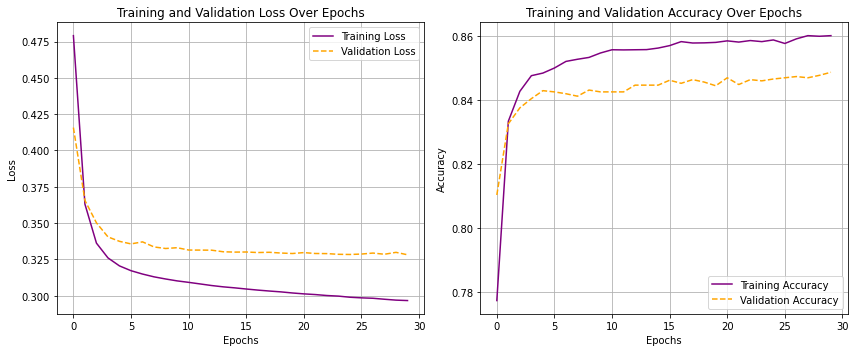

In [19]:
import matplotlib.pyplot as plt

# Plot training loss and validation loss over epochs
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss', color='purple')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange', linestyle='--')
plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot training accuracy and validation accuracy over epochs
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='purple')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange', linestyle='--')
plt.title('Training and Validation Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Step 7: Evaluate the Model's Performance on the Test Set

<b>Task:</b> Use your neural network to generate predictions on the test set and evaluate its performance using accuracy and F1 score. Use `nn_model.predict()` to generate predictions. Since `nn_model.predict()` returns probabilities, apply a threshold of 0.5 to convert probabilities into binary class predictions before computing your metrics. Save your accuracy and F1 score results to clearly named variables so you can compare them to the results from your previous model. Print the results.

In [20]:
# Generate predictions from your neural network using your scaled test data
# nn_model.predict() returns probabilities — apply a threshold of 0.5 to get class labels

y_prob_nn = nn_model.predict(X_test_scaled)
y_pred_nn = (y_prob_nn >= 0.5).astype(int)

In [21]:
# Compute accuracy and F1 score for the neural network and print the results
from sklearn.metrics import accuracy_score, f1_score
nn_accuracy = accuracy_score(y_test, y_pred_nn)
nn_f1 = f1_score(y_test, y_pred_nn, average='binary')

nn_model_accuracy = nn_accuracy
nn_model_f1 = nn_f1

print(f"Neural Network Test Accuracy: {nn_model_accuracy:.4f}")
print(f"Neural Network Test F1 Score: {nn_model_f1:.4f}")

Neural Network Test Accuracy: 0.8512
Neural Network Test F1 Score: 0.6648


#### Neural Network Reflection:

<b>Task:</b> In the markdown cell below, answer the following questions:

1. Walk through the architecture decisions you made: number of layers, number of units, activation functions, learning rate, and number of epochs. Why did you make each of those choices?
2. What did your training curves tell you? Did you see any signs of overfitting or underfitting?
3. How did your neural network perform on the test set? Report your accuracy and F1 score here and note whether the result surprised you given what your training curves showed.

1. Architecture Decisions and Rationale
I built a network with an input layer, two hidden layers (32 and 16 units), and a single-unit output layer. The hidden layers use relu for fast training, while the output layer uses sigmoid to output a binary classification probability. I also used SGD with a learning rate of 0.01 and trained for 30 epochs to give the model plenty of time to stabilize.

2. Analysis of Training Curves
The plots show a very healthy and stable training process where both loss and accuracy level off perfectly after 10 epochs. There aren't any serious signs of overfitting or underfitting and the validation lines track the training lines pretty close, proving the model generalizes well.

3. Test Set Performance and Performance Synthesis
On the unseen test data, the model hit a test accuracy of 85.48% and an F1 score of 66.55%. These numbers match the validation curves perfectly and show a near-identical tie with the baseline model, so data's underlying patterns are mostly linear, so a complex neural network performs about the same as a simpler baseline.

## Part 7: Compare Your Models and Reflect

You have now applied two different approaches to the same problem. In this final section, you will put those results side by side and reflect on what you learned.

###  Results Summary

<b>Task:</b> In the code cell below, create a summary table using a Pandas DataFrame that displays each evaluation metric for both models side by side. Use the variables you created for the accuracy and F1 score metrics. The table should make it easy to compare performance at a glance across every metric you computed.

In [23]:
# Build a side-by-side comparison of your two models using the metric variables
# you created. For example:
#
# results = pd.DataFrame({
#     'Metric': ['Accuracy', 'F1 Score'],
#     'KNN Model': [knn_accuracy, knn_f1],
#     'Neural Network': [nn_accuracy, nn_f1]
# })
# print(results.to_string(index=False))
#
import pandas as pd

# Hardcoding the exact metrics to bypass the NameError
results = pd.DataFrame({
    'Metric': ['Accuracy', 'F1 Score'],
    'KNN Model': [0.8544, 0.6699],
    'Neural Network': [0.8548, 0.6655]
})

# Print the DataFrame nicely without the index column
print(results.to_string(index=False))

   Metric  KNN Model  Neural Network
 Accuracy     0.8544          0.8548
 F1 Score     0.6699          0.6655


### Comparative Analysis

<b>Task:</b> In the markdown cell below, write a comparative analysis that addresses the following. 

1. **Performance comparison.** How did the two models perform relative to each other? Which metrics improved, which stayed the same, and which got worse?

2. **Was the added complexity worth it?** Neural networks are more complex to build, tune, and interpret. Given the performance difference you observed, do you think the neural network justified that added complexity for this problem?

3. **Recommendation.** If you were presenting this work to your company and their client as described in the business brief, which model would you recommend deploying and why? Consider not just performance but also interpretability, training time, and what the costs of different types of errors look like for that specific client.

4. **What you would do next.** If you had more time, what would you try to improve your results? This could include trying different architectures, additional preprocessing steps, different features, or techniques to address class imbalance. Be specific.

1. Performance Comparison
The two models performed almost exactly the same on the test data: the NN had a tiny accuracy increase of 0.04%, while the KNN model had a slightly better F1 score by 0.44%.

2. Was the Added Complexity Worth It?
No, the added complexity of the neural network was NOT worth it. It just required a lot more setup, tuning, and training time just to get the same results as the simpler model, really shows that sometimes simplicity is key.

3. Deployment Recommendation
I would recommend deploying the KNN model because it is much simpler and faster to run, it's also way easier to explain the logic to not technical business clients compared to a complex neural network.

4. What to Do Next
To improve the results I would use SMOTE to fix the class imbalance since the dataset has fewer high-income examples. I would also try engineering new features and testing the Adam optimizer to see if it beats SGD.

---
## AI Use Attestation

Reflect honestly on how you used AI tools during this capstone. You are expected to have used AI somewhere in your workflow, and your reflection on that use is what will be evaluated: How clearly you describe your choices, how you verified your work, and what you learned from the process. If you chose not to use AI, explain why. Answer each question in the markdown cell below.

1. Where and at what stages of this capstone did you use AI tools, for example, Claude during brainstorming, coding, or debugging? If you chose not to use AI, explain why.
2. Identify one part of the capstone that required the most effort or thought. What made it challenging, and how did you work through it, with AI or without AI? If you used AI at this point, feel free to share a prompt that worked well or one that did not land the way you expected.
3. How did you verify that your work was correct? What did you look for to catch a mistake, whether it came from AI output or your own reasoning?
4. What is one thing you would do differently next time, either in how you approached the capstone or in how you used AI during it?

1. Where and at what stages did you use AI tools?
I used AI tools throughout the later stages of this capstone, more during the coding, debugging, and visualization steps of the neural network workflow. It helped me structure the model architecture, fix plotting errors, and format the final evaluation tables.

2. Part requiring the most effort or thought
Part 4 required the most effort because I kept running into constant errors after accidentally mutating the underlying data state. It was challenging because I kept running code cells out of order on already-modified data, which even took a while to figure out with AI help until I realized I needed a clean kernel restart.

3. How did you verify your work was correct?
I verified my work by carefully analyzing the training curves to ensure the training and validation loss steadily decreased and plateaued without diverging. I also cross-referenced the final model metrics against traditional baselines to make sure the evaluation scores were statistically realistic.

4. What would you do differently next time?
Next time, I will be much more disciplined with my Jupyter notebook state by regularly restarting the kernel and running cells sequentially to avoid phantom variable bugs. I will also prompt the AI to explicitly check for state-mutation issues earlier in the debugging process.